Expects .asc files.

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm, CenteredNorm

import numpy as np
import os

data_dir = os.getcwd() + "/data/CL_Jan2026/"

Reading in phase data only.

In [3]:
fname = data_dir + "LCP Coating.asc"

f = open(fname, 'r')
IntfScaleFactor, WavelengthIn, ObliquityFactor, R = None, None, None, None
img_size_x, img_size_y = None, None
hash_in, n_hashes=False, 0
phase_img = []
for i, line in enumerate(f):
    l = line.strip()
    l = l.split()

    if i == 3: 
        img_size_x = int(l[2])
        img_size_y = int(l[3])
        print("Image size: ", img_size_x, "x", img_size_y)

    if i == 7:
        IntfScaleFactor = float(l[1])
        WavelengthIn = float(l[2])
        ObliquityFactor = float(l[4])
        print("IntfScaleFactor: ", IntfScaleFactor, "WavelengthIn: ", WavelengthIn, "ObliquityFactor: ", ObliquityFactor)

    elif i==10:
        phaseres = float(l[0])
        if phaseres == 0.0:
            R = 4096
        elif phaseres == 1.0:
            R = 32768
        else:
            ValueError("Phase resolution not 0 or 1")
        print("Phase resolution: {}".format(R))

    if l[0] == '#' and hash_in:
        # 2nd hash signifies data end
        break

    if hash_in:
        data = np.asarray(l, dtype=np.float128)
        phase_img.append(data)

    if l[0] == '#' and not hash_in:
        n_hashes += 1
    
    if n_hashes == 2:
        hash_in = True


Image size:  1151 x 1141
IntfScaleFactor:  0.5 WavelengthIn:  6.328e-07 ObliquityFactor:  1.0
Phase resolution: 32768


Text(0.5, 1.0, 'LCP Coating.asc - CL Zygo')

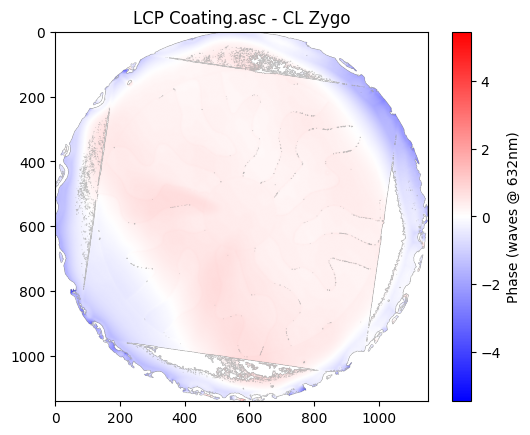

In [62]:
# phase_arr = np.asarray(phase_img)
# fx_img = np.append(phase_img[-1], 9223372036854775808)
# fx_list = phase_img[0:-1] + [fx_img]
# phase_arr = np.asarray(fx_list)
# %matplotlib qt
phase_arr = np.concatenate(phase_img)
reshaped_phase_arr = phase_arr.reshape(img_size_y, img_size_x)*(IntfScaleFactor*ObliquityFactor)/R #reshape and convert phase units to waves

# filter for pseudo-NaNs 
reshaped_phase_arr[reshaped_phase_arr == reshaped_phase_arr.max()] = np.nan

plt.imshow(reshaped_phase_arr, cmap='bwr', norm=CenteredNorm())
plt.colorbar(label='Phase (waves @ {:d}nm)'.format(int(WavelengthIn*1e9)))
plt.title("{} - CL Zygo".format(fname.split("/")[-1]))

In [63]:
np.save(fname[0:-4]+".npy", reshaped_phase_arr)

aside plotting

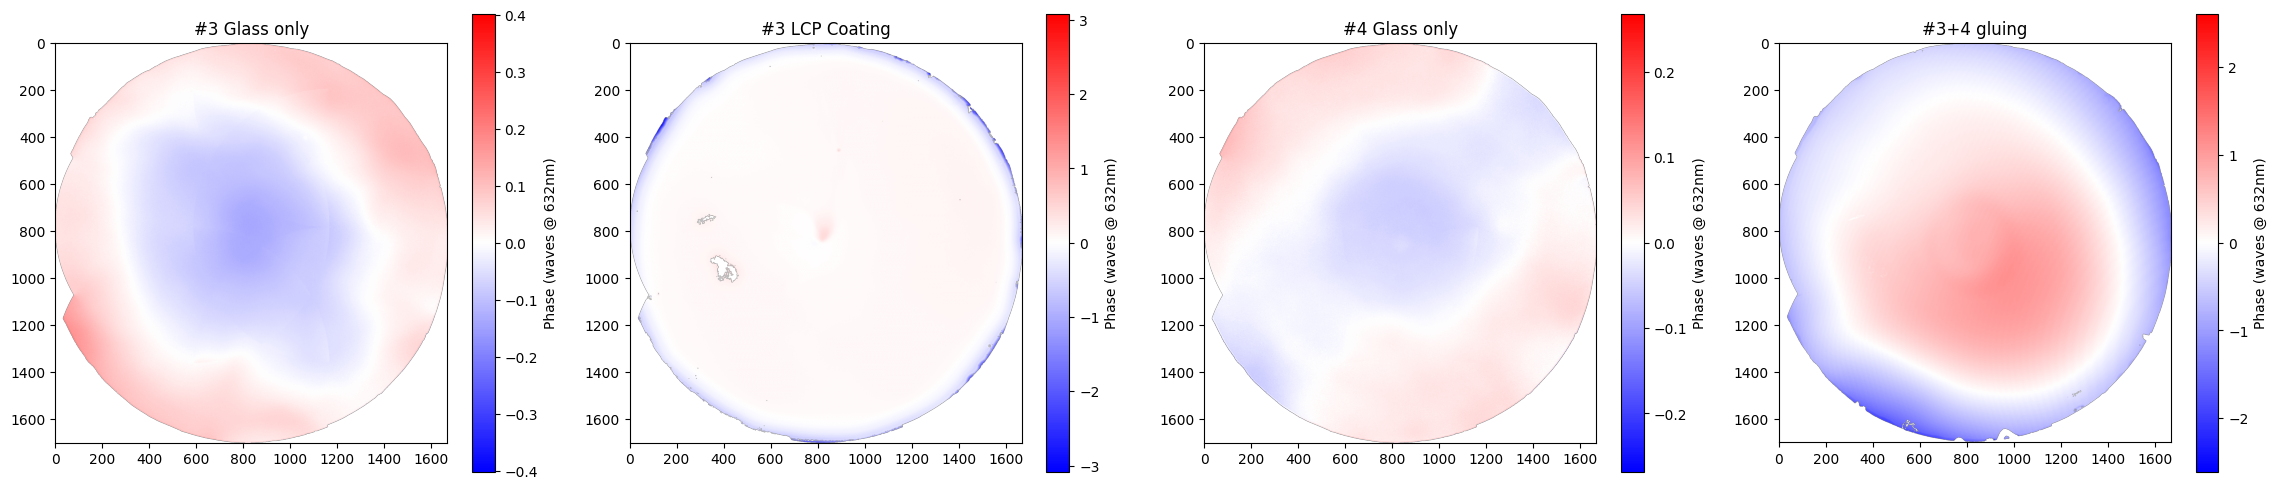

In [4]:
fnames = [
    "#3 Glass only.npy",
    "#3 LCP Coating.npy",
    "#4 Glass only.npy",
    "#3+4 gluing.npy",

]
plt.figure(figsize=(23,5))
for i, fname in enumerate(fnames):
    phase_arr = np.load(data_dir + fname)
    plt.subplot(1, len(fnames), i+1)
    plt.imshow(phase_arr, cmap='bwr', norm=CenteredNorm())
    plt.colorbar(label='Phase (waves @ {:d}nm)'.format(int(WavelengthIn*1e9)))
    plt.title(fname[0:-4])
plt.tight_layout()

0 ----
[ 3.36688618e-08 -1.22485307e-08  3.67174289e-10 -2.02542320e-09
 -1.91300515e-09 -5.49678379e-10 -1.14027537e-09 -6.89381625e-09
 -1.37394140e-09  1.77205480e-09  1.19258758e-10 -6.92258110e-11
 -8.72472936e-10  2.10881722e-09  9.11074669e-10  1.62955414e-09
 -8.44031651e-11  1.21734814e-09 -5.58225917e-10  1.16804384e-09
 -1.57056345e-11 -1.00401730e-09 -2.86919225e-09 -1.75621422e-10
 -3.13117964e-09 -2.60354322e-10  8.43626473e-10 -5.39568148e-10
  5.45804998e-10 -1.68384714e-09  1.35073478e-09 -9.97486034e-10]
1 ----
[-3.55674241e-08 -4.95669844e-09 -4.31646748e-10 -2.28921641e-09
 -8.87286478e-09  5.78661794e-09  2.45742201e-10 -4.00937707e-08
 -5.73940157e-09  3.32101422e-09  1.61931100e-09 -4.44052546e-09
 -8.69376207e-09 -5.40374970e-10  1.17363463e-09  4.01520368e-09
  6.31405462e-10  2.09506099e-09 -2.58783598e-08  7.67720568e-10
 -1.07246385e-09 -3.63639850e-09 -3.13671301e-10  9.24307826e-10
  3.06528472e-09  1.03564819e-09 -7.02737775e-09  4.53136575e-09
 -1.061755

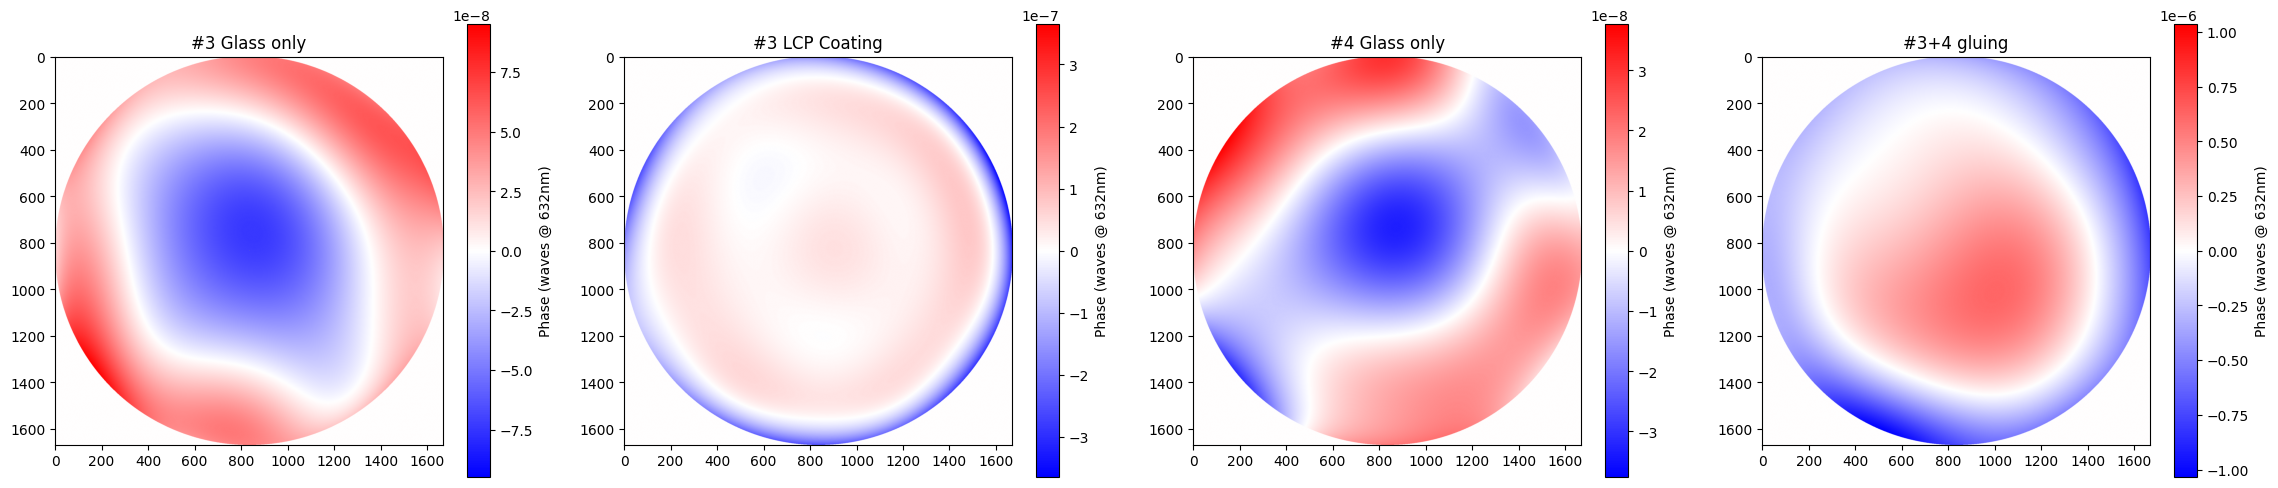

In [5]:
# fit with zernikes
import dLux.utils as dlu
aperture_diameter = 120e-3

plt.figure(figsize=(23,5))
for i, fname in enumerate(fnames):
    phase_arr = np.load(data_dir + fname)
    CL_opd = np.array(phase_arr, dtype=np.float64)
    n_rows, n_cols = CL_opd.shape
    cut_l = np.abs(n_rows - n_cols)
    is_odd = cut_l % 2
    if n_rows > n_cols:
        if is_odd:
            CL_opd = CL_opd[cut_l//2+1:-1-cut_l//2+1, :] 
        else:
            CL_opd = CL_opd[cut_l//2:-1-cut_l//2+1, :] 
    else:
        if is_odd:
            CL_opd = CL_opd[:, cut_l//2-2:-1-cut_l//2+1]
        else:
            CL_opd = CL_opd[:, cut_l//2:-1-cut_l//2+1]

    CL_opd[~np.isfinite(CL_opd)] = 0 # Replace inf/nan with 0

    CL_coords = dlu.pixel_coords(npixels=CL_opd.shape[0], diameter=aperture_diameter)
    CL_zbasis = dlu.zernike_basis(js=np.arange(4,36), diameter=aperture_diameter, coordinates=CL_coords)
    CL_zbasis_rshp = np.vstack([basis.flatten() for basis in CL_zbasis]).T
    CL_zbasis_rshp[~np.isfinite(CL_zbasis_rshp)] = 0 # Replace inf/nan with 0
    pinv = np.linalg.pinv(CL_zbasis_rshp)

    est_coeffs = pinv@(CL_opd.flatten()*WavelengthIn)
    print("{} ----".format(i))
    print(est_coeffs)
    retrieved = np.asarray([basis*est_coeffs[i] for i, basis in enumerate(CL_zbasis)]).sum(axis=0)
    plt.subplot(1, len(fnames), i+1)
    plt.imshow(retrieved, cmap='bwr', norm=CenteredNorm())
    plt.colorbar(label='Phase (waves @ {:d}nm)'.format(int(WavelengthIn*1e9)))
    plt.title(fname[0:-4])
plt.tight_layout()

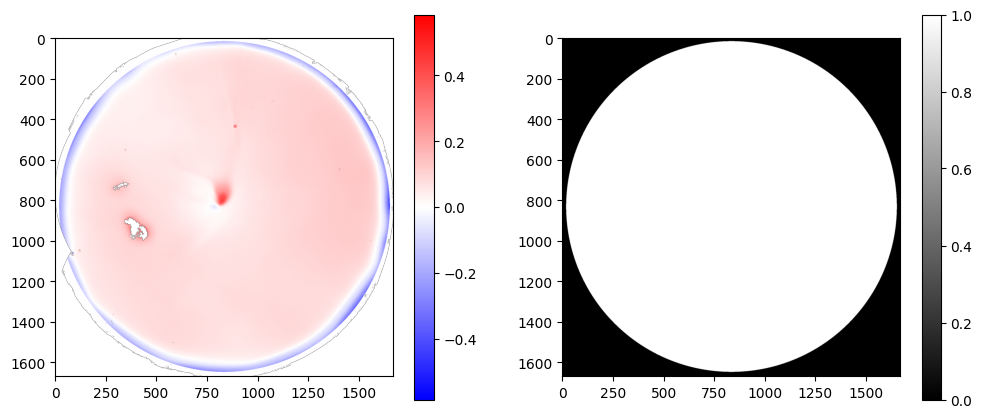

In [59]:
phase_arr = np.load(data_dir + "#3 LCP Coating.npy")
CL_opd = np.array(phase_arr, dtype=np.float64) 
n_rows, n_cols = CL_opd.shape
cut_l = np.abs(n_rows - n_cols)
is_odd = cut_l % 2
if n_rows > n_cols:
    if is_odd:
        CL_opd = CL_opd[cut_l//2+1:-1-cut_l//2+1, :] 
    else:
        CL_opd = CL_opd[cut_l//2:-1-cut_l//2+1, :] 
else:
    if is_odd:
        CL_opd = CL_opd[:, cut_l//2-2:-1-cut_l//2+1]
    else:
        CL_opd = CL_opd[:, cut_l//2:-1-cut_l//2+1]

CL_coords = dlu.pixel_coords(npixels=CL_opd.shape[0], diameter=aperture_diameter)
dlu_cover = dlu.circle(coords=CL_coords, radius=aperture_diameter/2.05)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(CL_opd*dlu_cover, cmap='bwr', norm=CenteredNorm())
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(dlu_cover, cmap='gray')
plt.colorbar()


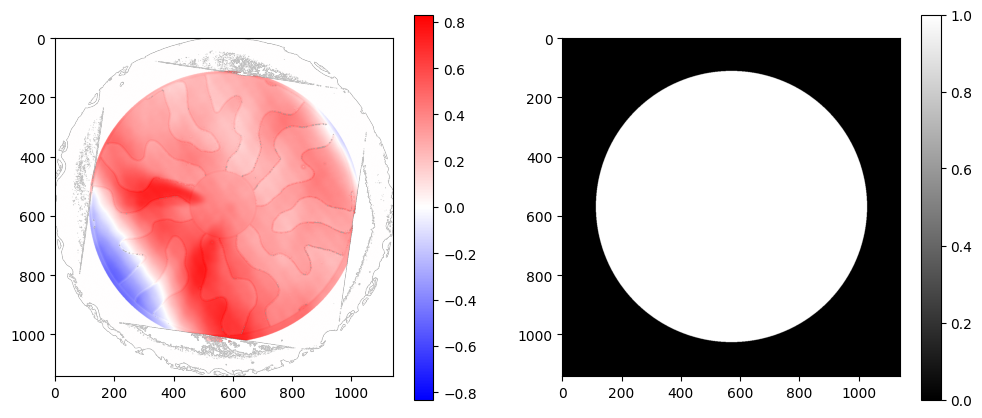

In [67]:
phase_arr = np.load(data_dir + "LCP Coating.npy")
CL_opd = np.array(phase_arr, dtype=np.float64) 
n_rows, n_cols = CL_opd.shape
cut_l = np.abs(n_rows - n_cols)
is_odd = cut_l % 2
if n_rows > n_cols:
    if is_odd:
        CL_opd = CL_opd[cut_l//2+1:-1-cut_l//2+1, :] 
    else:
        CL_opd = CL_opd[cut_l//2:-1-cut_l//2+1, :] 
else:
    if is_odd:
        CL_opd = CL_opd[:, cut_l//2-2:-1-cut_l//2+1]
    else:
        CL_opd = CL_opd[:, cut_l//2:-1-cut_l//2+1]

CL_coords = dlu.pixel_coords(npixels=CL_opd.shape[0], diameter=aperture_diameter)
dlu_cover = dlu.circle(coords=CL_coords, radius=aperture_diameter/2.5)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(CL_opd*dlu_cover, cmap='bwr', norm=CenteredNorm())
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(dlu_cover, cmap='gray')
plt.colorbar()
